In [2]:
# analyzing real-world Data
# 
# Applying probability and statistics to real-world data

# Applying
#   -Applying probability concepts to understnad distributions of data
#   -Applying Hypothesis testing to identify significant relationships or differences
#   -regression analysis to explore and quantify relatioonships between variables


In [3]:
# performing EDA
# Steps in EDA
    # -Load and inspect dataset
    # -check for missing or inconsistent data
    # -Visualize distributions and relationships using histograms, scatterplots, and correlation heatmaps

# key goals:
    # -Understand the data structure
    # -Identify patterns, trends, and outliers



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


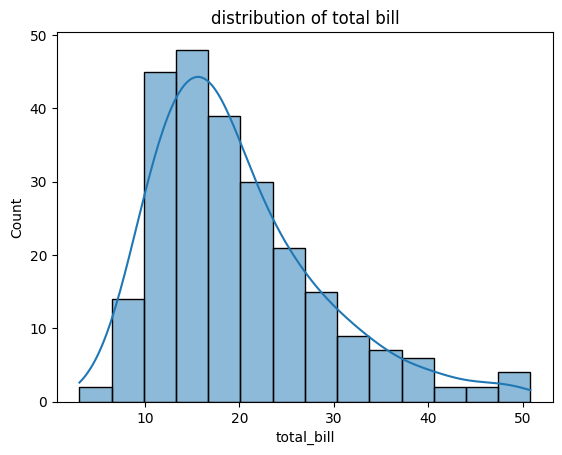

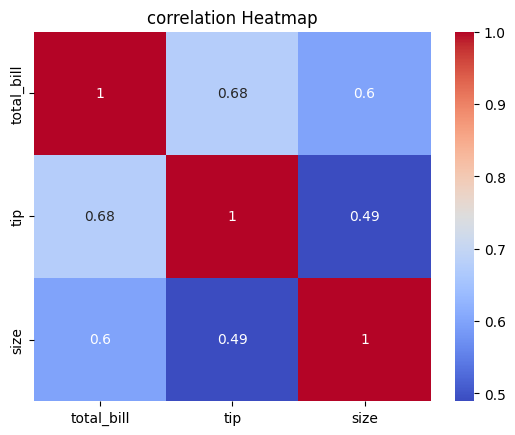

In [14]:
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset
df=pd.read_csv(url)

# inspect the data
print(df.info())
print(df.describe())

# check for missing or inconsistent data
df.isnull()

# visualize Distributions
sns.histplot(df['total_bill'], kde=True)
plt.title("distribution of total bill")
plt.show()

del df['sex']
del df['smoker']
del df['day']
del df['time']
# correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("correlation Heatmap")
plt.show()


In [1]:
# conducting Hypothesis testing
# steps:
    # -formulate null and alternative hypothesis
    # -choose and perform an appropriate hypothesis ex t-test or chio squared test
    # interpret p-values
    

In [5]:
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

from scipy.stats import ttest_ind

import pandas as pd

# load the dataset
df=pd.read_csv(url)

# seperate data by gender
male_tips=df[df['sex']=='Male']['tip']
female_tips=df[df['sex']=='Female']['tip']

# perform ttest
t_stat, p_value=ttest_ind(male_tips,female_tips)
print("t_statistic: ",t_stat)
print("p_value: ",p_value)

# interpet results
alpha=0.05
if p_value<=alpha:
    print("reject all null hypothesis: Significant difference")
else:
    print("fail to reject all null hypothesis: no Significant difference")




t_statistic:  1.387859705421269
p_value:  0.16645623503456755
fail to reject all null hypothesis: no Significant difference


intercept:  0.9202696135546731
slope:  0.10502451738435337
r_squared:  0.45661658635167657


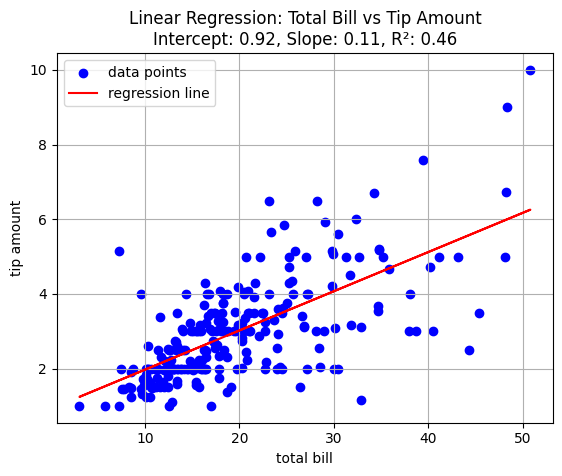

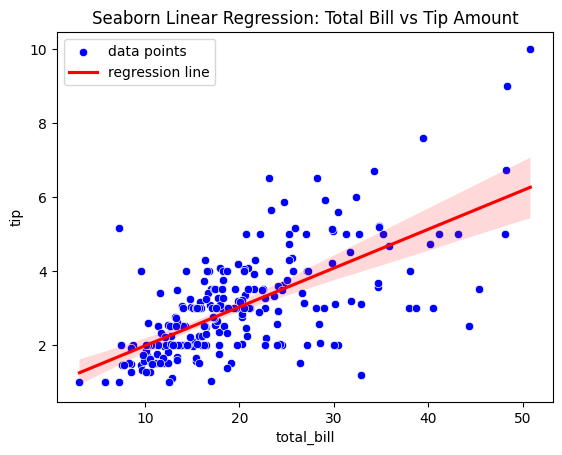

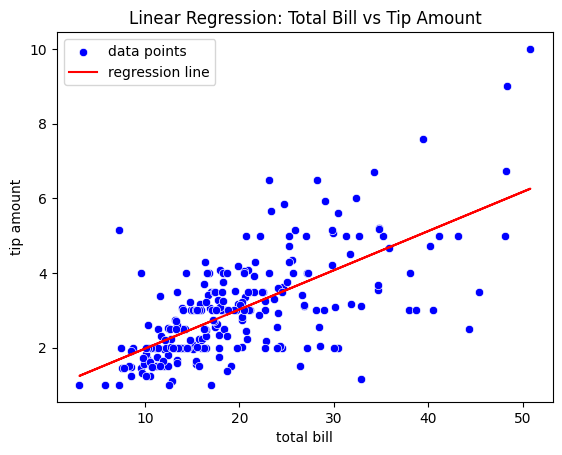

In [21]:
# applying linear regression
# steps:
    # -select dependent and independent variables
    # -fit a linear regression model
    # -evaluate model performance using R-squared and residual analysis

# example: Analyzing relationship between total bill and tip amount

url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

import pandas as pd
# from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# load the dataset
df=pd.read_csv(url)

# define variables
x=df['total_bill'].values.reshape(-1,1) #here reshape is used to convert 1D array to 2D array with one column and multiple rows
# -1 means infer the number of rows automatically and 1 means one column
y=df['tip'].values

# fit linear regression model
model=LinearRegression()
model.fit(x,y)

# outputs coefficients
print("intercept: ",model.intercept_)
print("slope: ",model.coef_[0])
print('r_squared: ',model.score(x,y))

# visualize regression line
plt.scatter(x,y,color='blue',label='data points')
plt.plot(x,model.predict(x),color='red',label='regression line')
plt.xlabel('total bill')
plt.ylabel('tip amount')
plt.title(f'Linear Regression: Total Bill vs Tip Amount\nIntercept: {model.intercept_:.2f}, Slope: {model.coef_[0]:.2f}, R²: {model.score(x,y):.2f}')
plt.legend()
plt.grid()
plt.show()

# visualize using seaborn
import seaborn as sns

sns.scatterplot(x='total_bill', y='tip', data=df,color='blue',label='data points')
sns.regplot(x='total_bill', y='tip', data=df, scatter=False, color='red',label='regression line')
plt.title('Seaborn Linear Regression: Total Bill vs Tip Amount')
plt.legend()
plt.show()


# visualise plot regression
sns.scatterplot(x=df['total_bill'], y=df['tip'],color='blue',label='data points')
plt.plot(df['total_bill'], model.predict(x), color='red', label='regression line')
plt.xlabel('total bill')
plt.ylabel('tip amount')
plt.title('Linear Regression: Total Bill vs Tip Amount')
plt.legend()
plt.show()

In [ ]:
# hands on projects
# 1.Statistical Analysis of real-world Dataset
    # -perform EDA on a dataset to uncover patterns and insights
    # -conduct hypothesis testing to determine significant differences between groups
    # -apply linear regression to model relationships between variables and evaluate model performance
    # -

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   size        244 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 5.8 KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


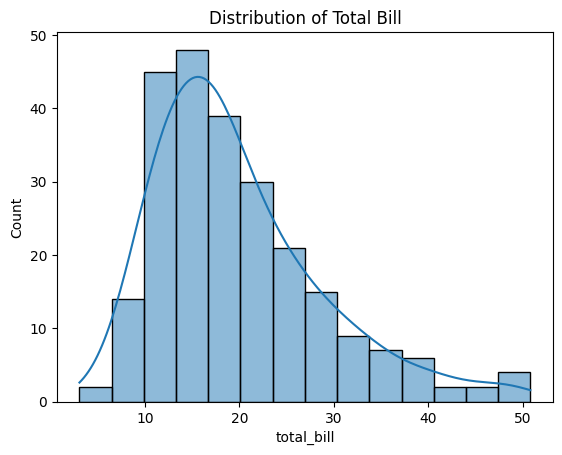

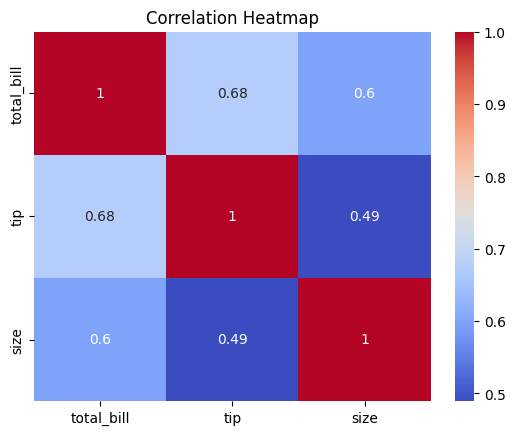

In [25]:
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df=pd.read_csv(url)

# delete unnecessary columns
del df['sex']
del df['smoker']
del df['day']
del df['time']

# 1. EDA
# inspect the data
print(df.info())
print(df.describe())

# visualize distributions
sns.histplot(df['total_bill'], kde=True)
plt.title("Distribution of Total Bill")
plt.show()


sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



Chi-squared Statistic:  25.787216672396262
p-value:  1.0567572499836523e-05
Degrees of Freedom:  3
Expected Frequencies: 
 [[11.75819672 53.84016393 47.03278689 38.36885246]
 [ 7.24180328 33.15983607 28.96721311 23.63114754]]
reject null hypothesis: Significant association between smoking status and day of the week


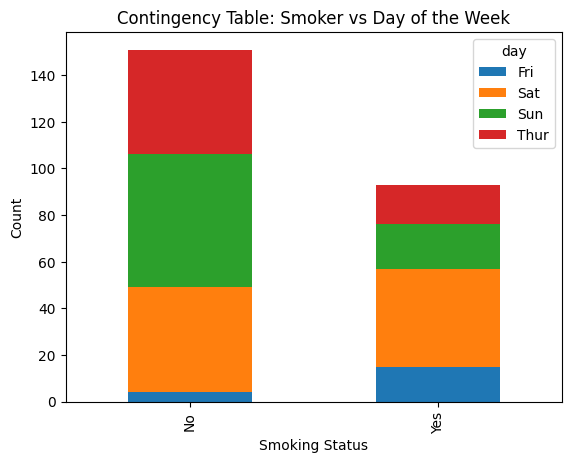

In [32]:
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

df=pd.read_csv(url)
# 2. Hypothesis Testing
from scipy.stats import ttest_ind, chi2_contingency

contingency_table=pd.crosstab(df['smoker'], df['day'])
chi2, p_value, dof, expected=chi2_contingency(contingency_table)

print("Chi-squared Statistic: ", chi2)
print("p-value: ", p_value)
print("Degrees of Freedom: ", dof)
print("Expected Frequencies: \n", expected)

# interpret results
alpha=0.05
if p_value<=alpha:
    print("reject null hypothesis: Significant association between smoking status and day of the week")
else:
    print("fail to reject null hypothesis: No Significant association between smoking status and day of the week")

# visualize contingency table
contingency_table.plot(kind='bar', stacked=True)
plt.title("Contingency Table: Smoker vs Day of the Week")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.show()


intercept:  0.9202696135546731
slope:  0.10502451738435337
r_squared:  0.45661658635167657


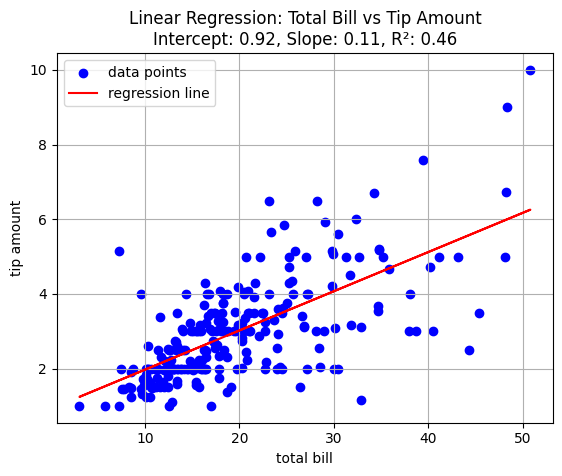

In [31]:
# 3. Linear Regression

url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

# define variables
x=df['total_bill'].values.reshape(-1,1)
y=df['tip'].values

# fit linear regression model
model=LinearRegression()
model.fit(x,y)

# outputs coefficients
print("intercept: ",model.intercept_)
print("slope: ",model.coef_[0])
print('r_squared: ',model.score(x,y))

# visualize regression line
plt.scatter(x,y,color='blue',label='data points')
plt.plot(x,model.predict(x),color='red',label='regression line')
plt.xlabel('total bill')
plt.ylabel('tip amount')
plt.title(f'Linear Regression: Total Bill vs Tip Amount\nIntercept: {model.intercept_:.2f}, Slope: {model.coef_[0]:.2f}, R²: {model.score(x,y):.2f}')
plt.legend()
plt.grid()
plt.show()

F_statistic:  1.6723551980998697
p_value:  0.17358855530405823
fail to reject null hypothesis: no Significant difference in tip amounts between days of the week


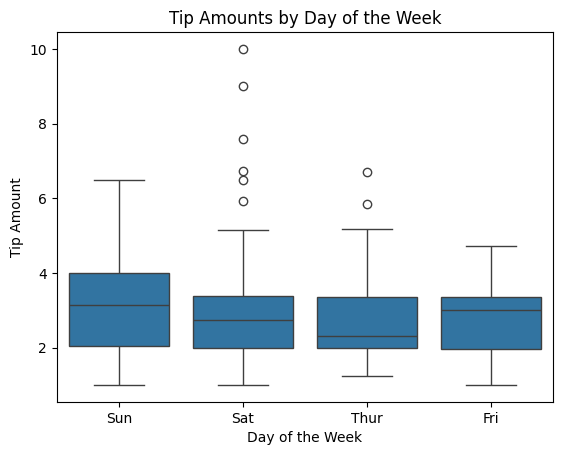

intercept:  2.55618234157797
slope:  0.16221279496988755
r_squared:  0.018359914997966853


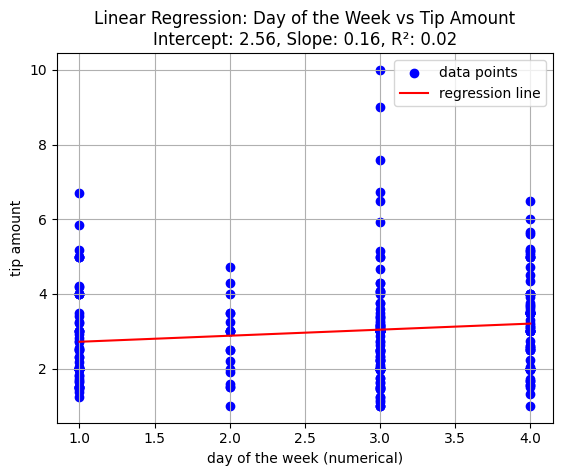

In [36]:

# 2.Extend the project by Exploring additional variables or using advanced statistical techniques to gain deeper insights into the dataset  (eg day of the week vs tip amount)

url='https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'

# conduct hypothesis testing between day of the week and tip amount

from scipy.stats import f_oneway
import pandas as pd
# load the dataset
df=pd.read_csv(url)
# seperate tip amounts by day of the week

tip_thur=df[df['day']=='Thur']['tip']
tip_fri=df[df['day']=='Fri']['tip']
tip_sat=df[df['day']=='Sat']['tip']
tip_sun=df[df['day']=='Sun']['tip']

# perform ANOVA test
f_stat, p_value=f_oneway(tip_thur, tip_fri, tip_sat, tip_sun)
print("F_statistic: ",f_stat)
print("p_value: ",p_value)

# interpret results
alpha=0.05
if p_value<=alpha:
    print("reject null hypothesis: Significant difference in tip amounts between days of the week")
else:
    print("fail to reject null hypothesis: no Significant difference in tip amounts between days of the week")


# visualize tip amounts by day of the week
sns.boxplot(x='day', y='tip', data=df)
plt.title("Tip Amounts by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Tip Amount")
plt.show()


# Applying Linear Regression to model relationship day of the week vs tip amount

# define variables

day_mapping={'Thur':1,'Fri':2,'Sat':3,'Sun':4}
df['day_num']=df['day'].map(day_mapping)
x=df['day_num'].values.reshape(-1,1)
y=df['tip'].values

# fit linear regression model
model=LinearRegression()
model.fit(x,y)

# outputs coefficients
print("intercept: ",model.intercept_)
print("slope: ",model.coef_[0])
print('r_squared: ',model.score(x,y))

# visualize regression line
plt.scatter(x,y,color='blue',label='data points')
plt.plot(x,model.predict(x),color='red',label='regression line')
plt.xlabel('day of the week (numerical)')
plt.ylabel('tip amount')
plt.title(f'Linear Regression: Day of the Week vs Tip Amount\nIntercept: {model.intercept_:.2f}, Slope: {model.coef_[0]:.2f}, R²: {model.score(x,y):.2f}')
plt.legend()
plt.grid()

plt.show()

In [ ]:
# perfomr multiple linear regression to predict tip amount based on total bill and day of the week
# use another real-world dataset(eg healthcare or sales data) to perform similar statistical analysis and modeling